## YOLO11m + Уточнение сегментации ROI

**Цель:**
Двухэтапный конвейер обработки ран со структурированными экспериментами по сегментации.

Этап 1: YOLO11m-seg обнаруживает ограничивающие рамки и грубые маски ран.

Этап 2: Конфигурируемая модель сегментации ROI (`unetplusplus` — базовая, опционально `deeplabv3plus`) уточняет маски на обрезанных областях интереса.

Этот ноутбук поддерживает:
- Обучение только на GT ROI
- Смешанное обучение GT / jitter / кэшированные YOLO ROI
- Перебор разрешений (256 / 384 / 512)
- Функция потерь с учётом границ
- Многомасштабное уточнение в комбинированном конвейере

**Набор данных:**
`data/wound_focus_clean/` с готовым разделением на train / val / test.


## 1: Настройка / Импорт / Конфигурация

In [1]:
%matplotlib inline

import json
import math
import sys
import time
import platform
from datetime import datetime
from pathlib import Path
from typing import Dict, List, Optional

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml

SCRIPT_DIR = Path.cwd().resolve()
# Обучение из ноутбука: рабочая директория должна быть experiments/YOLO11m_UNetPP
if not (SCRIPT_DIR / "config.yaml").is_file() or not (SCRIPT_DIR / "train_model.py").is_file():
    raise RuntimeError(
        "Kernel working directory must be experiments/YOLO11m_UNetPP "
        f"(config.yaml + train_model.py not found in {SCRIPT_DIR})"
    )
PROJECT_ROOT = SCRIPT_DIR.parent.parent
sys.path.insert(0, str(SCRIPT_DIR))

from pipeline_utils import (
    set_seed,
    get_device,
    load_config,
    prepare_yolo_dataset,
    validate_yolo_dataset,
    create_unet_datasets,
    make_unet_dataloaders,
    unet_collate_fn,
    WoundDataset,
    IMAGENET_MEAN,
    IMAGENET_STD,
    WOUND_ONLY_CLASSES,
)
from train_model import (
    build_yolo_model,
    train_yolo,
    evaluate_yolo,
    predict_yolo,
    build_segmentation_model,
    build_unet_model,
    train_unet,
    build_unet_criterion,
    train_one_epoch_unet,
    validate_one_epoch_unet,
    evaluate_unet_metrics,
    save_unet_checkpoint,
    load_unet_checkpoint,
    save_unet_training_curves,
    combined_inference,
    evaluate_combined,
    calculate_wound_area,
    predict_single_image,
    generate_report,
    save_global_metrics_summary,
    display_results_predictions,
)

print("=" * 60)
print("Библиотеки успешно импортированы")
print("=" * 60)
print(f"PyTorch: {torch.__version__}")
print(f"CUDA:    {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:     {torch.cuda.get_device_name(0)}")
print("=" * 60)

# Загрузка конфигурации (валидация секции combined через CombinedInferenceConfig)
CONFIG = load_config(SCRIPT_DIR / "config.yaml", validate_combined=True)
set_seed(CONFIG.get("seed", 42))
device = get_device()

# Пути к директориям
output_dir = SCRIPT_DIR / "checkpoints"
results_dir = SCRIPT_DIR / "results"
reports_dir = SCRIPT_DIR / "reports"
for d in [output_dir, results_dir, reports_dir]:
    d.mkdir(parents=True, exist_ok=True)

print(f"\nDevice: {device}")
print(f"Experiment name: {CONFIG.get('experiment_name')}")
print(f"\nConfiguration:")
for section in ["yolo", "unet", "combined"]:
    print(f"\n  [{section.upper()}]")
    for k, v in CONFIG.get(section, {}).items():
        print(f"    {k}: {v}")

_unet = CONFIG.get("unet", {})
_comb = CONFIG.get("combined", {})
print("\n[Segmentation experiment lock]")
print(
    f"  architecture={_unet.get('architecture')}, "
    f"input_size={_unet.get('input_size')}, "
    f"roi_crop_mode={_unet.get('roi_crop_mode')}, "
    f"loss_type={_unet.get('loss_type')}, "
    f"resume_checkpoint={_unet.get('resume_checkpoint')}"
)
print("\n[Combined pipeline lock]")
print(
    f"  yolo_conf_thresh={_comb.get('yolo_conf_thresh')}, "
    f"unet_mask_thresh={_comb.get('unet_mask_thresh')}, "
    f"roi_padding={_comb.get('roi_padding')}, "
    f"multi_scale_refinement={_comb.get('multi_scale_refinement')}, "
    f"multi_scale_fusion={_comb.get('multi_scale_fusion')}, "
    f"refinement_postprocess={_comb.get('refinement_postprocess')}"
)

Библиотеки успешно импортированы
PyTorch: 2.5.1+cu121
CUDA:    True
GPU:     NVIDIA GeForce RTX 4060 Laptop GPU

Device: cuda
Experiment name: None

Configuration:

  [YOLO]
    model: yolo11m-seg.pt
    image_size: 768
    batch_size: 4
    epochs: 60
    lr0: 0.01
    lrf: 0.01
    optimizer: SGD
    momentum: 0.937
    weight_decay: 0.0005
    patience: 15
    degrees: 7
    perspective: 0.0
    flipud: 0.0
    fliplr: 0.5
    mosaic: 0.3
    mixup: 0.0
    close_mosaic: 15
    hsv_h: 0.01
    hsv_s: 0.5
    hsv_v: 0.3

  [UNET]
    architecture: unetplusplus
    encoder: efficientnet-b1
    encoder_weights: imagenet
    input_size: [384, 384]
    in_channels: 3
    classes: 1
    batch_size: 8
    epochs: 50
    lr: 0.0001
    weight_decay: 0.0001
    optimizer: AdamW
    scheduler: CosineAnnealingLR
    scheduler_T_max: 45
    scheduler_eta_min: 1e-06
    early_stop_patience: 8
    loss_type: focal_dice
    loss_bce_weight: 0.4
    loss_dice_weight: 0.6
    loss_boundary_weight: 0

## 2: Валидация и загрузка набора данных

In [2]:
# ============================================================================
# 2.1 Конвертация аннотаций COCO в формат сегментации YOLO
# ============================================================================

print("Конвертация COCO -> формат меток YOLO...")
dataset_yaml = prepare_yolo_dataset(CONFIG, SCRIPT_DIR)
print(f"\nDataset YAML: {dataset_yaml}")

print("\nВалидация набора данных YOLO...")
is_valid = validate_yolo_dataset(dataset_yaml)
if not is_valid:
    raise RuntimeError("YOLO dataset validation FAILED.")
print()

# ============================================================================
# 2.2 Создание ROI-наборов данных и загрузчиков для U-Net++
# ============================================================================

print("Создание ROI-наборов данных U-Net++...")
unet_train_ds, unet_val_ds, unet_test_ds = create_unet_datasets(CONFIG, SCRIPT_DIR)
print(f"  ROI samples — Train: {len(unet_train_ds)}, Val: {len(unet_val_ds)}, Test: {len(unet_test_ds)}")

unet_cfg = CONFIG["unet"]
unet_train_loader, unet_val_loader = make_unet_dataloaders(
    unet_train_ds, unet_val_ds,
    batch_size=unet_cfg.get("batch_size", 16),
    num_workers=CONFIG.get("num_workers", 0),
)
unet_test_loader = torch.utils.data.DataLoader(
    unet_test_ds,
    batch_size=unet_cfg.get("batch_size", 16),
    shuffle=False,
    num_workers=CONFIG.get("num_workers", 0),
    pin_memory=torch.cuda.is_available(),
    collate_fn=unet_collate_fn,
)

# ============================================================================
# 2.3 Создание набора данных для оценки (полные изображения для комбинированного конвейера)
# ============================================================================

data_root = (PROJECT_ROOT / CONFIG["data_root"]).resolve()
test_ann = (PROJECT_ROOT / CONFIG["ann_test"]).resolve()
eval_dataset = WoundDataset(
    root=str(data_root),
    annotation_file=str(test_ann),
    image_size=(CONFIG["yolo"].get("image_size", 640), CONFIG["yolo"].get("image_size", 640)),
)
print(f"  Full-image test set: {len(eval_dataset)} images")

Конвертация COCO -> формат меток YOLO...
  Converting train (train_augmented.json) ...
    -> 1028 label files written to E:\GitHub\Wound-infection-detection-model\data\wound_focus_clean\augmented\labels
  Converting val (val_wound_only.json) ...
    -> 57 label files written to E:\GitHub\Wound-infection-detection-model\data\wound_focus_clean\labels
  Converting test (test_wound_only.json) ...
    -> 55 label files written to E:\GitHub\Wound-infection-detection-model\data\wound_focus_clean\labels

Dataset YAML: E:\GitHub\Wound-infection-detection-model\experiments\YOLO11m_UNetPP\yolo_data\dataset.yaml

Валидация набора данных YOLO...
[OK] train: 1028 images listed, spot-check passed
[OK] train: YOLO label paths (images->labels) exist; 50/50 sample .txt non-empty
[OK] val: 57 images listed, spot-check passed
[OK] val: YOLO label paths (images->labels) exist; 50/50 sample .txt non-empty
[OK] test: 55 images listed, spot-check passed
[OK] test: YOLO label paths (images->labels) exist; 50/

e:\GitHub\Wound-infection-detection-model\.venv_cuda\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## 3: Визуализация образцов и инициализация модели

In [3]:
# ============================================================================
# 3.1 Визуализация обучающих ROI-образцов U-Net++ с GT-масками
# ============================================================================

NUM_VIS = 4
fig, axes = plt.subplots(2, NUM_VIS, figsize=(4 * NUM_VIS, 8))

mean_t = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std_t = torch.tensor(IMAGENET_STD).view(3, 1, 1)

for idx in range(min(NUM_VIS, len(unet_train_ds))):
    img_tensor, mask_tensor = unet_train_ds[idx]
    img_np = (img_tensor * std_t + mean_t).permute(1, 2, 0).cpu().numpy()
    img_np = np.clip(img_np, 0, 1)
    mask_np = mask_tensor.squeeze().cpu().numpy()

    axes[0, idx].imshow(img_np)
    axes[0, idx].set_title(f"ROI crop {idx}")
    axes[0, idx].axis("off")

    axes[1, idx].imshow(mask_np, cmap="gray")
    axes[1, idx].set_title(f"GT mask {idx}")
    axes[1, idx].axis("off")

fig.suptitle("Обучающие ROI U-Net++ с GT-масками", fontsize=13)
fig.tight_layout()
plt.show()

# ============================================================================
# 3.2 Построение моделей
# ============================================================================

print("\nПостроение модели YOLO11m-seg...")
yolo_model = build_yolo_model(CONFIG["yolo"].get("model", "yolo11m-seg.pt"))
print(f"  YOLO model loaded: {CONFIG['yolo'].get('model', 'yolo11m-seg.pt')}")

print("\nПостроение модели сегментации ROI...")
unet_model = build_segmentation_model(CONFIG)
unet_model.to(device)
n_params = sum(p.numel() for p in unet_model.parameters())
print(f"  Segmentation model on {device} ({n_params:,} parameters)")
print(
    f"  Architecture: {CONFIG['unet'].get('architecture', 'unetplusplus')} | "
    f"Encoder: {CONFIG['unet']['encoder']} | Input: {CONFIG['unet']['input_size']}"
)

C:\Users\Ul8ziz\AppData\Local\Temp\ipykernel_59920\812181166.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()



Построение модели YOLO11m-seg...
  YOLO model loaded: yolo11m-seg.pt

Построение модели сегментации ROI...
  Segmentation model on cuda (9,075,217 parameters)
  Architecture: unetplusplus | Encoder: efficientnet-b1 | Input: [384, 384]


## 4: Цикл обучения / Валидация / Контрольные точки

In [4]:
# ============================================================================
# 4.1 Этап 1 — YOLO11m-seg training
# ============================================================================

print("Начало этапа 1: Обучение YOLO11m-seg")
print("=" * 60)

yolo_results = train_yolo(CONFIG, SCRIPT_DIR)
yolo_test_metrics = evaluate_yolo(CONFIG, SCRIPT_DIR)
yolo_results.update(yolo_test_metrics)

print("\n" + "=" * 60)
print("Обучение YOLO завершено")
print("=" * 60)
for k, v in yolo_test_metrics.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")

# ============================================================================
# 4.2 Этап 2 — ROI segmentation training
# ============================================================================

from experiment_io import get_unet_dirs

print("\n\nНачало этапа 2: Обучение сегментации ROI")
print("=" * 60)

unet_results_summary = train_unet(CONFIG, SCRIPT_DIR)
best_dice = float(unet_results_summary.get("best_dice", 0.0))
best_epoch = int(unet_results_summary.get("best_epoch", 0))
unet_test_metrics = dict(unet_results_summary.get("test_metrics", {}))

results_unet = get_unet_dirs(SCRIPT_DIR, CONFIG)["results"]
with open(results_unet / "training_history.json", "r", encoding="utf-8") as f:
    unet_history = json.load(f)

print(f"\nЛучший Dice: {best_dice:.4f} на эпохе {best_epoch}")
print(
    f"Время обучения: {unet_results_summary.get('training_time_s', 0):.0f}с "
    f"({unet_results_summary.get('training_time_s', 0)/60:.1f} min)"
)

Начало этапа 1: Обучение YOLO11m-seg

Stage 1: Training YOLO11m-seg
New https://pypi.org/project/ultralytics/8.4.36 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.31  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=E:\GitHub\Wound-infection-detection-model\experiments\YOLO11m_UNetPP\yolo_data\dataset.yaml, degrees=7, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.01, hsv_s=0.5, hsv_v=0.3, imgsz=768, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=

e:\GitHub\Wound-infection-detection-model\.venv_cuda\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


  ROI samples — Train: 1144, Val: 85, Test: 74
  U-Net++ on cuda (9,075,217 params)
  Checkpoints: E:\GitHub\Wound-infection-detection-model\experiments\YOLO11m_UNetPP\checkpoints\unet
  Results:     E:\GitHub\Wound-infection-detection-model\experiments\YOLO11m_UNetPP\results\unet
  Config:      E:\GitHub\Wound-infection-detection-model\experiments\YOLO11m_UNetPP\results\unet\config_snapshot.yaml

Epoch [1/50]
----------------------------------------
  Epoch [1] [0/143] Loss: 0.4442
  Epoch [1] [10/143] Loss: 0.4326
  Epoch [1] [20/143] Loss: 0.4009
  Epoch [1] [30/143] Loss: 0.3611
  Epoch [1] [40/143] Loss: 0.3448
  Epoch [1] [50/143] Loss: 0.3335
  Epoch [1] [60/143] Loss: 0.3789
  Epoch [1] [70/143] Loss: 0.3472
  Epoch [1] [80/143] Loss: 0.2687
  Epoch [1] [90/143] Loss: 0.3127
  Epoch [1] [100/143] Loss: 0.2895
  Epoch [1] [110/143] Loss: 0.2687
  Epoch [1] [120/143] Loss: 0.2523
  Epoch [1] [130/143] Loss: 0.2535
  Epoch [1] [140/143] Loss: 0.3008
  Train Loss: 0.3293 | Val Loss

In [5]:
# ============================================================================
# Сохранение кривых обучения для обеих моделей
# ============================================================================

print("Сохранение кривых обучения U-Net++...")
save_unet_training_curves(unet_history, results_unet)

print("\nСохранение предсказаний YOLO...")
predict_yolo(CONFIG, SCRIPT_DIR)

print("\nКривые обучения сохранены на диск.")
print("Используйте раздел 5 (Обзор) для визуализации объединённых кривых.")

Сохранение кривых обучения U-Net++...
  -> Saved U-Net++ curves to E:\GitHub\Wound-infection-detection-model\experiments\YOLO11m_UNetPP\results\unet\unet_training_curves.png

Сохранение предсказаний YOLO...
  -> Saved 8 YOLO predictions to E:\GitHub\Wound-infection-detection-model\experiments\YOLO11m_UNetPP\results\yolo\predictions

Кривые обучения сохранены на диск.
Используйте раздел 5 (Обзор) для визуализации объединённых кривых.


## 5: Качественные предсказания / Отчёты / Сводка и обзор

Файл: task_163_img_000186_infected.jpg
Площадь раны: 76.8 см² | Infection: non_infected | Confidence: 0.83


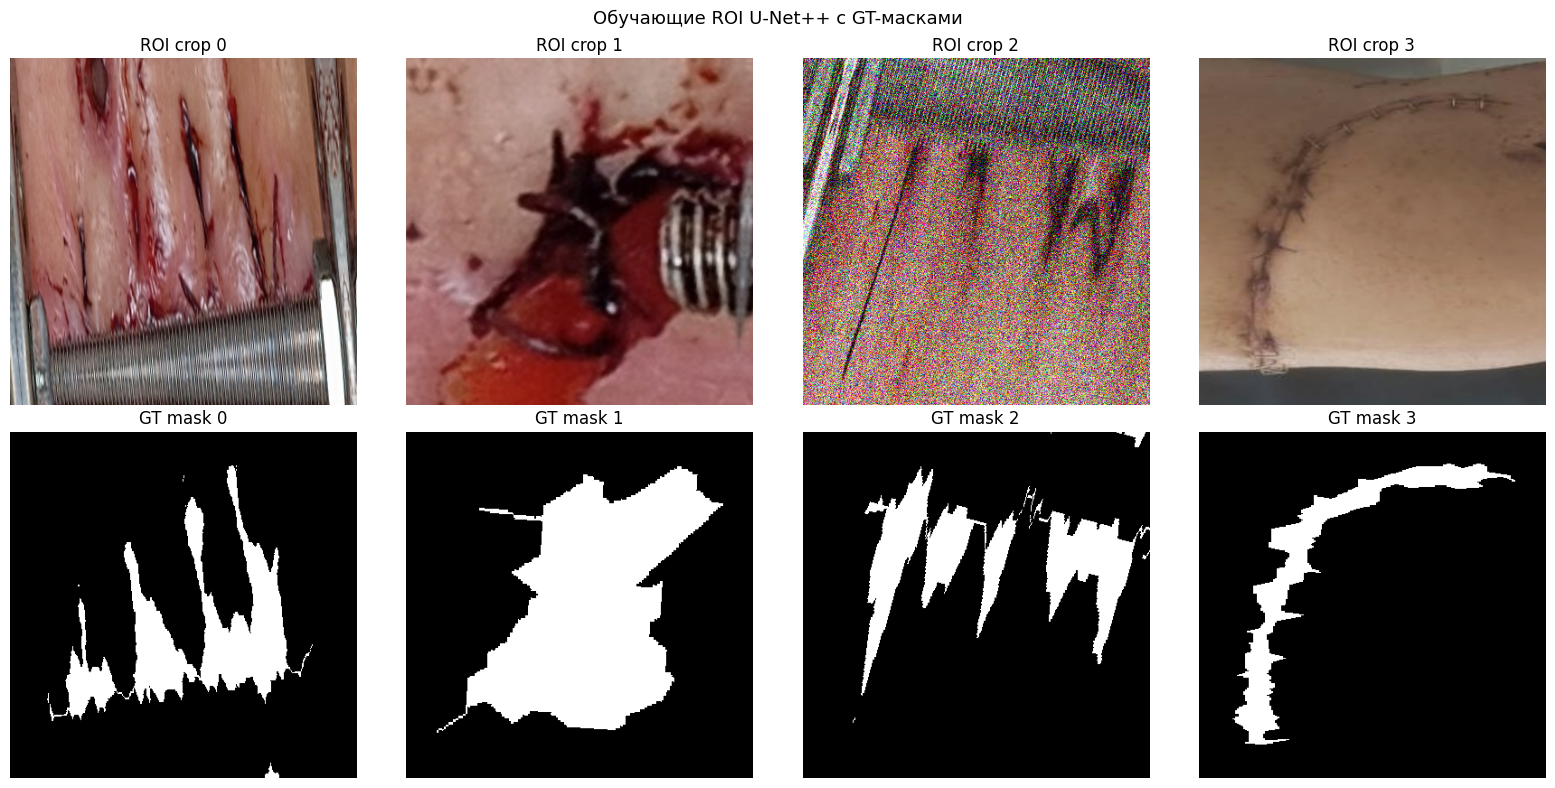

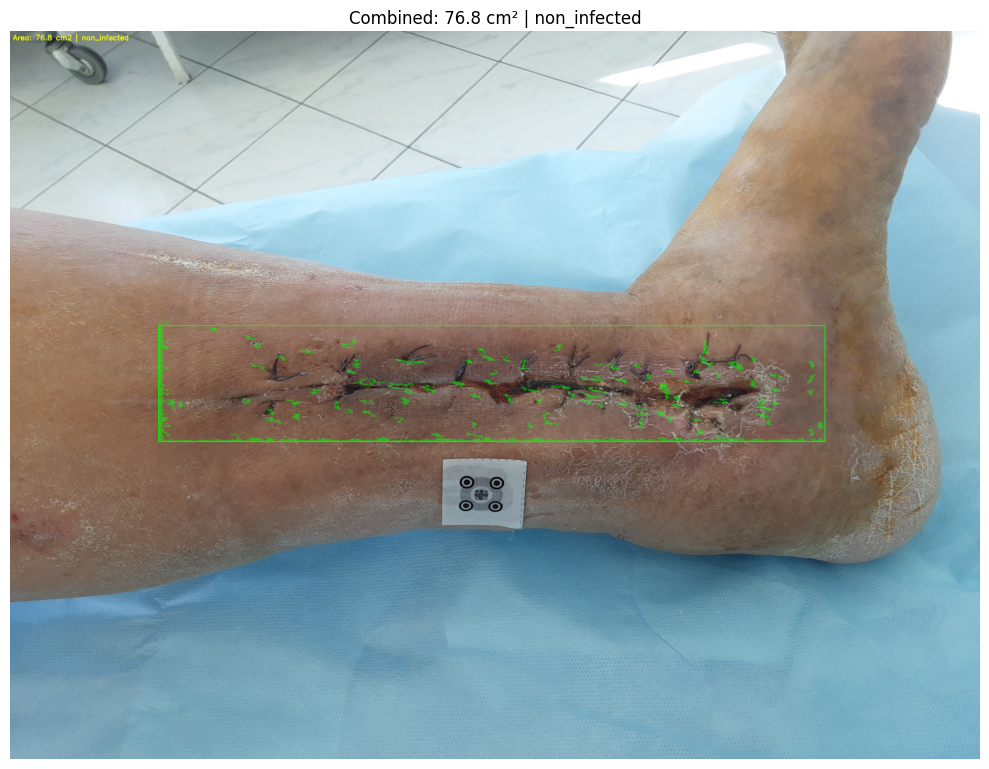


Запуск комбинированной оценки на полном тестовом наборе...

Stage 3: Combined YOLO11m + U-Net++ Evaluation
  Results dir: E:\GitHub\Wound-infection-detection-model\experiments\YOLO11m_UNetPP\results\combined
  Config:      E:\GitHub\Wound-infection-detection-model\experiments\YOLO11m_UNetPP\results\combined\config_snapshot.yaml
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.01s).
Accumulating evaluation results...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.481
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.750
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.522
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.059
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=mediu

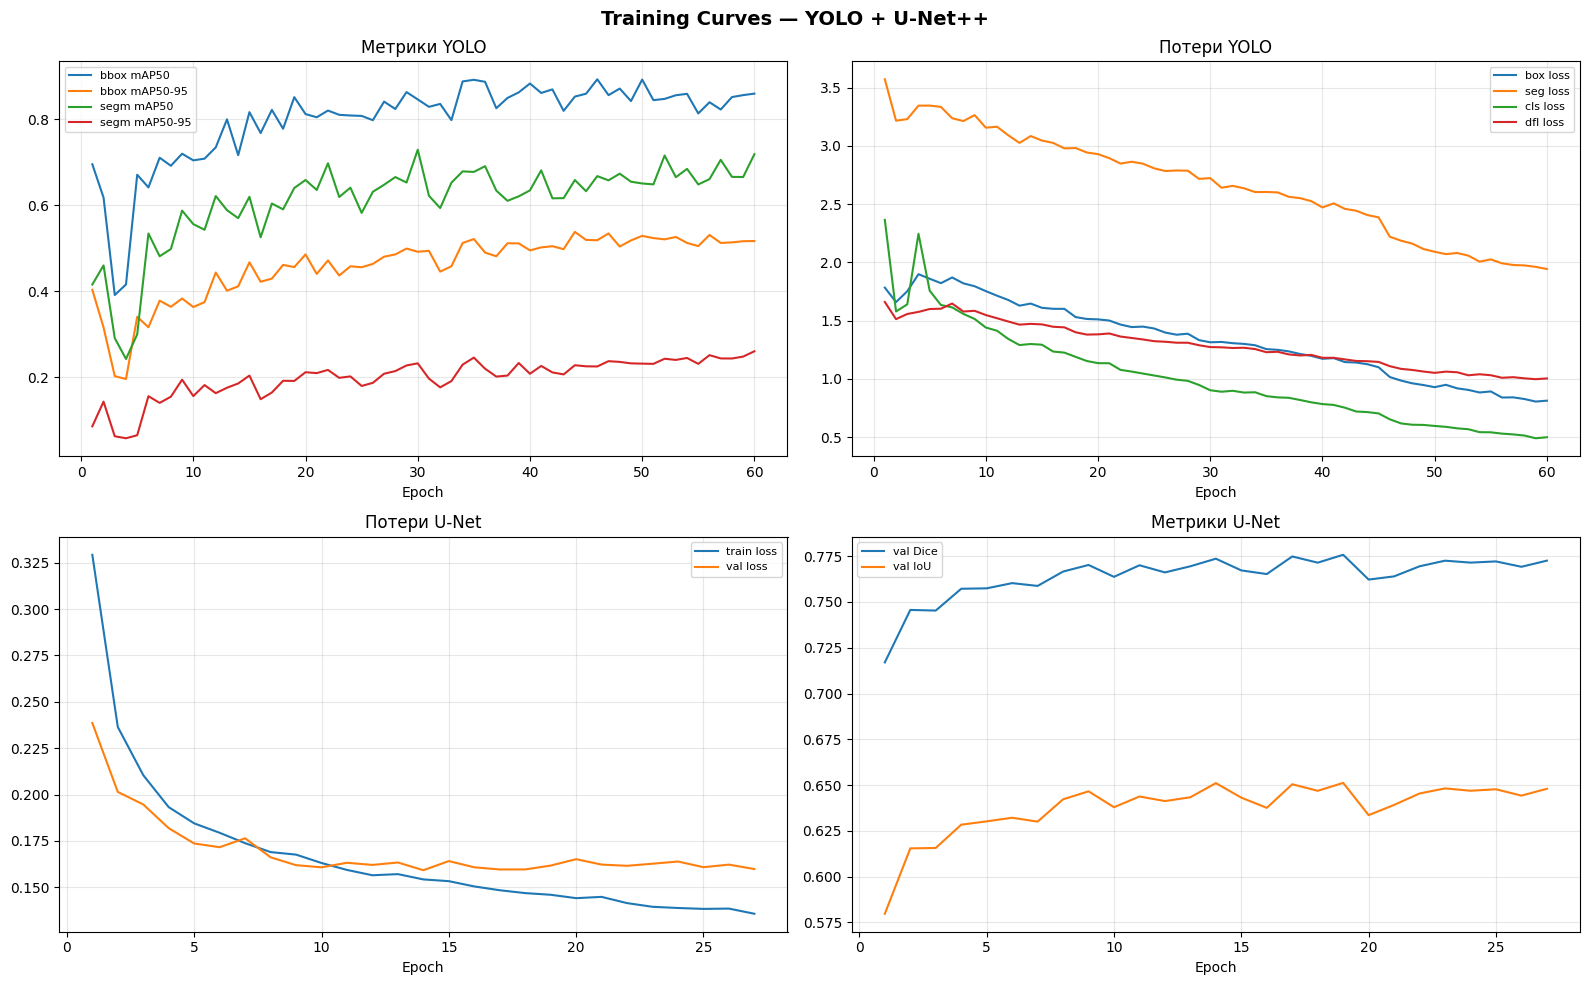


КАЧЕСТВЕННЫЕ ПРЕДСКАЗАНИЯ


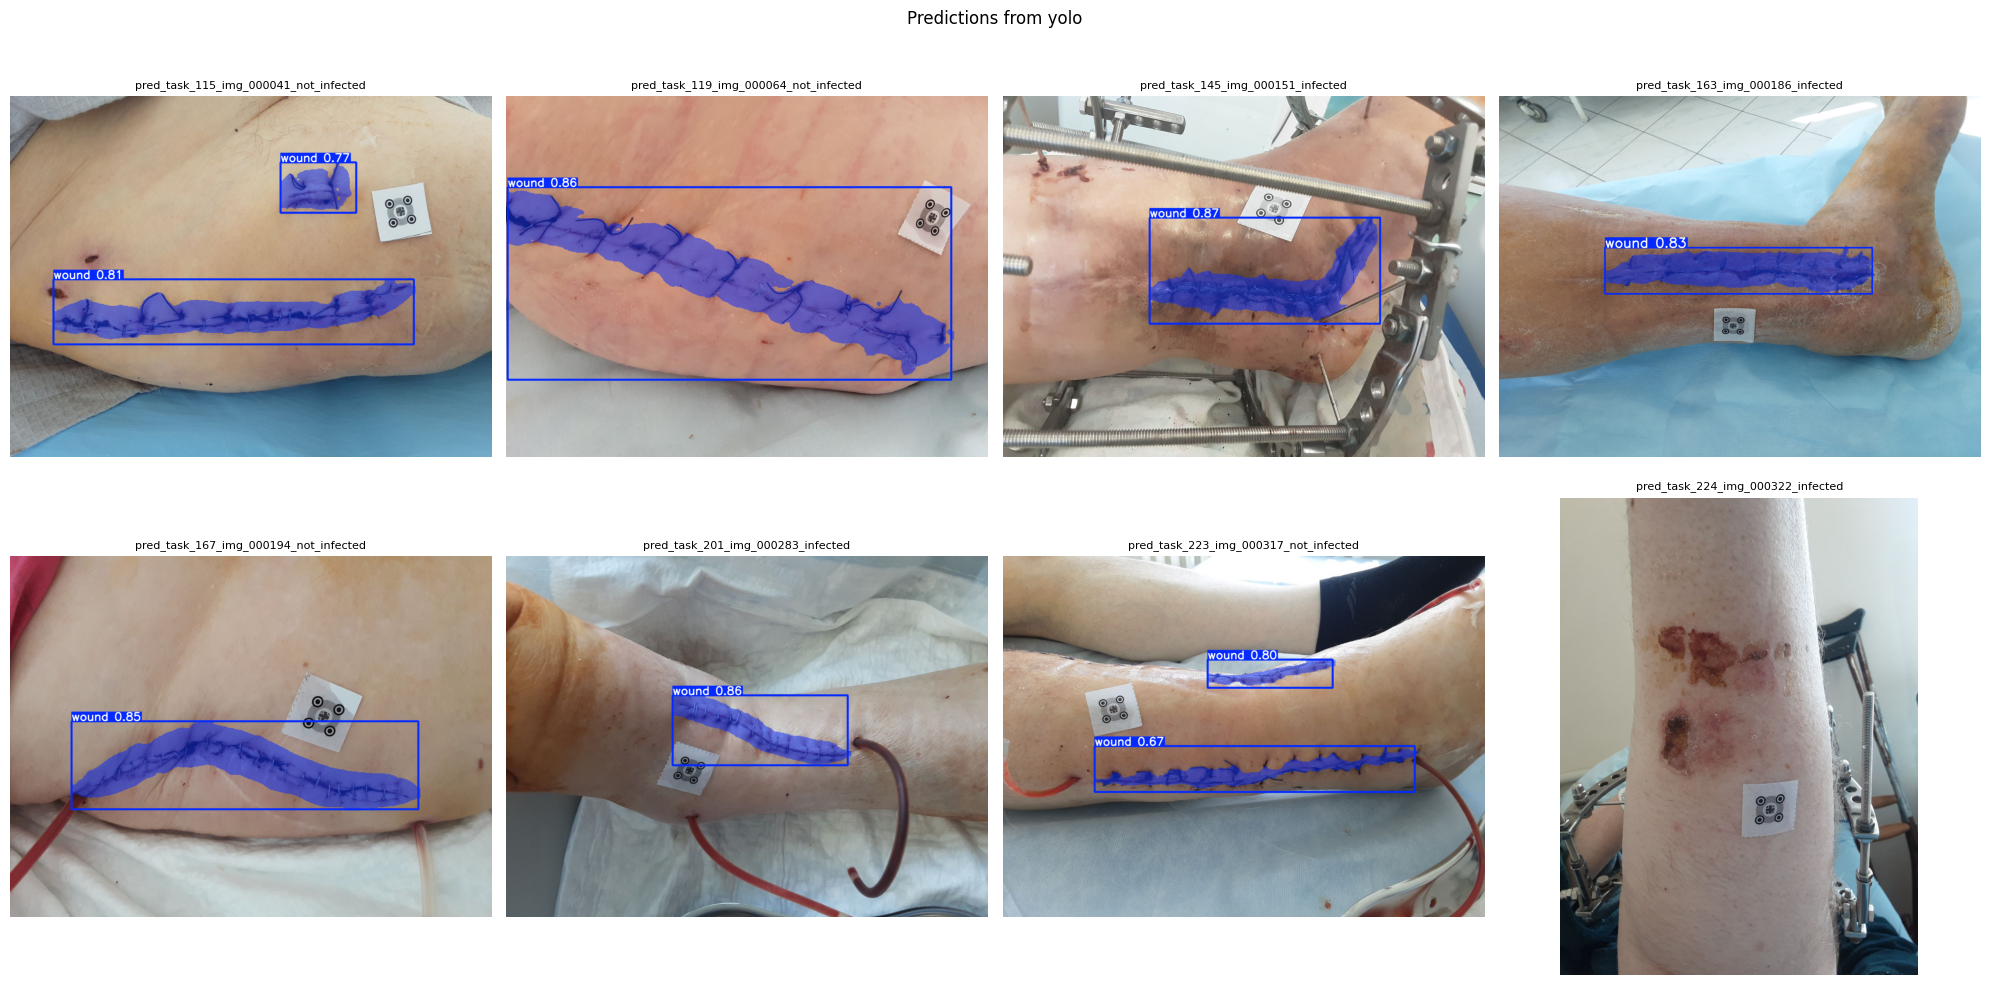

---

## Результаты комбинированного конвейера

| Metric | Value |
|--------|-------|
| mean_dice | 0.6694928697639307 |
| mean_iou | 0.5490610143723371 |
| mean_dice_conditional | 0.6818908858706701 |
| mean_iou_conditional | 0.5592288109347878 |
| n_images_total | 55 |
| n_images_evaluated | 54 |
| n_images_missed | 1 |
| n_predictions_saved | 8 |
| coco_bbox_AP | 0.4805462958206544 |
| coco_bbox_AP50 | 0.7501815919575405 |
| coco_bbox_AP75 | 0.5222656302384545 |
| coco_segm_AP | 0.1984375086895963 |
| coco_segm_AP50 | 0.561053652319715 |
| coco_segm_AP75 | 0.09908720253309644 |
| coco_combined_AP50 | 0.6556176221386278 |
| coco_combined_AP75 | 0.3106764163857755 |

---

## Результаты классификации инфекции

*Нет данных.*


КОНТРОЛЬНЫЕ ТОЧКИ

  yolo/
    best.pt (43.0 MB)
    last.pt (43.0 MB)

  unet/
    best_model.pth (101.5 MB)
    last_checkpoint.pth (101.5 MB)


In [6]:
%matplotlib inline

import sys
import json
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

# ============================================================================
# Инициализация — эта ячейка работает даже без запуска §1–§4 first
# ============================================================================

if "SCRIPT_DIR" not in globals():
    SCRIPT_DIR = Path.cwd().resolve()
if not (SCRIPT_DIR / "config.yaml").is_file() or not (SCRIPT_DIR / "train_model.py").is_file():
    raise RuntimeError(
        "Kernel cwd must be experiments/YOLO11m_UNetPP "
        f"(config.yaml + train_model.py not found in {SCRIPT_DIR})"
    )
if str(SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPT_DIR))
if "PROJECT_ROOT" not in globals():
    PROJECT_ROOT = SCRIPT_DIR.parent.parent

if "CONFIG" not in globals():
    from pipeline_utils import load_config, set_seed, get_device
    CONFIG = load_config(SCRIPT_DIR / "config.yaml", validate_combined=True)
    set_seed(CONFIG.get("seed", 42))
    device = get_device()
elif "device" not in globals():
    from pipeline_utils import get_device
    device = get_device()

if "data_root" not in globals() or "test_ann" not in globals():
    data_root = (PROJECT_ROOT / CONFIG["data_root"]).resolve()
    test_ann = (PROJECT_ROOT / CONFIG["ann_test"]).resolve()

if "results_dir" not in globals():
    results_dir = SCRIPT_DIR / "results"
    reports_dir = SCRIPT_DIR / "reports"
    for d in (results_dir, reports_dir):
        d.mkdir(parents=True, exist_ok=True)

from train_model import (
    build_yolo_model,
    predict_single_image,
    evaluate_combined,
    save_global_metrics_summary,
    generate_report,
    build_segmentation_model,
    load_unet_checkpoint,
    display_results_predictions,
)
from experiment_io import get_unet_dirs, get_combined_dirs, get_unet_best_checkpoint_path

if "unet_model" not in globals():
    unet_model = build_segmentation_model(CONFIG)
    unet_model.to(device)
    _ckpt = get_unet_best_checkpoint_path(SCRIPT_DIR, CONFIG)
    if _ckpt.is_file():
        load_unet_checkpoint(unet_model, _ckpt, device)
    else:
        print("[ВНИМАНИЕ] Контрольная точка U-Net не найдена; using random weights.")

if "yolo_model" not in globals():
    yolo_model = build_yolo_model(CONFIG["yolo"].get("model", "yolo11m-seg.pt"))

if "yolo_results" not in globals():
    _yp = SCRIPT_DIR / "results" / "yolo" / "test_metrics.json"
    if _yp.is_file():
        with open(_yp, "r", encoding="utf-8") as f:
            yolo_results = json.load(f)
    else:
        yolo_results = {}

if "unet_results_summary" not in globals():
    _ud = get_unet_dirs(SCRIPT_DIR, CONFIG)["results"]
    _usp = _ud / "metrics_summary.json"
    if _usp.is_file():
        with open(_usp, "r", encoding="utf-8") as f:
            unet_results_summary = json.load(f)
    else:
        unet_results_summary = {"best_dice": 0.0, "best_epoch": 0, "test_metrics": {}}

if "best_dice" not in globals():
    best_dice = float(unet_results_summary.get("best_dice", 0.0))
if "best_epoch" not in globals():
    best_epoch = int(unet_results_summary.get("best_epoch", 0))
if "unet_test_metrics" not in globals():
    unet_test_metrics = dict(unet_results_summary.get("test_metrics", {}))

# ════════════════════════════════════════════════════════════════════════════
# ЧАСТЬ A — Qualitative Predictions / Reports / Summary  (old §5)
# ════════════════════════════════════════════════════════════════════════════

# --- 5.1 Комбинированная инференция — single image example ---
yolo_best_path = SCRIPT_DIR / "checkpoints" / "yolo" / "best.pt"
if yolo_best_path.exists():
    yolo_model_best = build_yolo_model(str(yolo_best_path))
else:
    print("[ВНИМАНИЕ] YOLO best.pt не найден — using base model.")
    yolo_model_best = yolo_model

with open(str(test_ann), "r", encoding="utf-8") as f:
    test_coco = json.load(f)
test_images = test_coco["images"]

if test_images:
    sample_img = test_images[0]
    sample_path = str(data_root / sample_img["file_name"])

    overlay, info = predict_single_image(
        yolo_model_best, unet_model, sample_path, device, CONFIG,
    )
    print(f"Файл: {info['file_name']}")
    print(f"Площадь раны: {info.get('wound_area_cm2', 'N/A')} см² | "
          f"Infection: {info.get('infection', 'N/A')} | "
          f"Confidence: {info.get('confidence', 0):.2f}")

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    ax.set_title(f"Combined: {info.get('wound_area_cm2', '')} cm² | {info.get('infection', '')}")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

# --- 5.2 Полная комбинированная оценка on test set ---
print("\nЗапуск комбинированной оценки на полном тестовом наборе...")
combined_metrics = evaluate_combined(CONFIG, SCRIPT_DIR)

# --- 5.3 Сохранение глобальных метрик and generate report ---
save_global_metrics_summary(
    yolo_results, unet_results_summary, combined_metrics,
    CONFIG, results_dir,
)
generate_report(
    yolo_results, unet_results_summary, combined_metrics,
    CONFIG, reports_dir,
)

print("\n" + "=" * 80)
print("Сводка обучения и оценки")
print("=" * 80)
print(f"YOLO bbox mAP50:     {yolo_results.get('bbox_mAP50', 'N/A')}")
print(f"YOLO segm mAP50:     {yolo_results.get('segm_mAP50', 'N/A')}")
print(f"Лучший Dice U-Net++:   {best_dice:.4f} (эпоха {best_epoch})")
print(f"Тестовый Dice U-Net++:   {unet_test_metrics.get('dice', 'N/A')}")
print(f"Средний Dice конвейера:  {combined_metrics.get('mean_dice', 'N/A')}")
print(f"Средний IoU конвейера:   {combined_metrics.get('mean_iou', 'N/A')}")
print("=" * 80)

# ════════════════════════════════════════════════════════════════════════════
# ЧАСТЬ B — Review: Display Saved Curves and Predictions  (old §6)
# ════════════════════════════════════════════════════════════════════════════

# --- Сводка глобальных метрик ---
print("\n" + "=" * 60)
print("СВОДКА ГЛОБАЛЬНЫХ МЕТРИК")
print("=" * 60)

print("\n--- YOLO11m-seg ---")
for k in ["bbox_mAP50", "bbox_mAP50_95", "segm_mAP50", "segm_mAP50_95", "combined_AP50"]:
    print(f"  {k}: {yolo_results.get(k, 'N/A')}")

print("\n--- U-Net++ ---")
print(f"  Лучший Dice (val): {unet_results_summary.get('best_dice', 'N/A')}")
print(f"  Лучшая эпоха:      {unet_results_summary.get('best_epoch', 'N/A')}")
for k in ["dice", "iou", "pixel_accuracy"]:
    print(f"  Test {k}: {unet_test_metrics.get(k, 'N/A')}")

print("\n--- Combined Pipeline ---")
comb_dirs = get_combined_dirs(SCRIPT_DIR, CONFIG)
comb_metrics_path = comb_dirs["results"] / "metrics_summary.json"
if comb_metrics_path.exists():
    with open(comb_metrics_path, "r", encoding="utf-8") as f:
        _comb_metrics = json.load(f)
    for k in ["mean_dice", "mean_iou", "n_images_evaluated",
              "coco_bbox_AP50", "coco_bbox_AP75",
              "coco_segm_AP50", "coco_segm_AP75",
              "coco_combined_AP50", "coco_combined_AP75"]:
        print(f"  {k}: {_comb_metrics.get(k, 'N/A')}")
else:
    print("  (metrics_summary.json not found — run combined evaluation first)")

# --- Объединённые кривые обучения ---
print("\n" + "=" * 60)
print("КРИВЫЕ ОБУЧЕНИЯ")
print("=" * 60)

unet_dirs = get_unet_dirs(SCRIPT_DIR, CONFIG)
yolo_csv_path = SCRIPT_DIR / "checkpoints" / "yolo" / "train" / "results.csv"
unet_json_path = unet_dirs["results"] / "training_history.json"

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

if yolo_csv_path.exists():
    df = pd.read_csv(yolo_csv_path)
    df.columns = [c.strip() for c in df.columns]
    epoch_col = "epoch" if "epoch" in df.columns else df.columns[0]

    ax = axes[0, 0]
    for col, label in [
        ("metrics/mAP50(B)", "bbox mAP50"),
        ("metrics/mAP50-95(B)", "bbox mAP50-95"),
        ("metrics/mAP50(M)", "segm mAP50"),
        ("metrics/mAP50-95(M)", "segm mAP50-95"),
    ]:
        if col in df.columns:
            ax.plot(df[epoch_col], df[col], label=label)
    ax.set_title("Метрики YOLO"); ax.set_xlabel("Epoch")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    ax = axes[0, 1]
    for col, label in [
        ("train/box_loss", "box loss"), ("train/seg_loss", "seg loss"),
        ("train/cls_loss", "cls loss"), ("train/dfl_loss", "dfl loss"),
    ]:
        if col in df.columns:
            ax.plot(df[epoch_col], df[col], label=label)
    ax.set_title("Потери YOLO"); ax.set_xlabel("Epoch")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
else:
    axes[0, 0].text(0.5, 0.5, "YOLO results.csv not found", ha="center", va="center")
    axes[0, 1].text(0.5, 0.5, "YOLO results.csv not found", ha="center", va="center")

if unet_json_path.exists():
    with open(unet_json_path, "r", encoding="utf-8") as f:
        hist = json.load(f)
    _tl = hist.get("train_losses") or hist.get("train_loss") or []
    _vl = hist.get("val_losses") or hist.get("val_loss") or []
    _vd = hist.get("dice_per_epoch") or hist.get("val_dice") or []
    _vi = hist.get("iou_per_epoch") or hist.get("val_iou") or []
    epochs_list = list(range(1, len(_tl) + 1))

    ax = axes[1, 0]
    if _tl:
        ax.plot(epochs_list, _tl, label="train loss")
    if _vl:
        ax.plot(epochs_list, _vl, label="val loss")
    ax.set_title("Потери U-Net"); ax.set_xlabel("Epoch")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    ax = axes[1, 1]
    if _vd:
        ax.plot(epochs_list, _vd, label="val Dice")
    if _vi:
        ax.plot(epochs_list, _vi, label="val IoU")
    ax.set_title("Метрики U-Net"); ax.set_xlabel("Epoch")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
else:
    axes[1, 0].text(0.5, 0.5, "U-Net history not found", ha="center", va="center")
    axes[1, 1].text(0.5, 0.5, "U-Net history not found", ha="center", va="center")

fig.suptitle("Training Curves — YOLO + U-Net++", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

# --- Качественные предсказания ---
print("\n" + "=" * 60)
print("КАЧЕСТВЕННЫЕ ПРЕДСКАЗАНИЯ")
print("=" * 60)
display_results_predictions(SCRIPT_DIR / "results", n_show=8)

# --- COCO Markdown-отчёт комбинированного конвейера ---
if comb_metrics_path.exists():
    with open(comb_metrics_path, "r", encoding="utf-8") as f:
        _m = json.load(f)
    md_lines = ["---", "", "## Результаты комбинированного конвейера", "",
                "| Metric | Value |", "|--------|-------|"]
    for k, v in _m.items():
        md_lines.append(f"| {k} | {v} |")
    md_lines += ["", "---", "", "## Результаты классификации инфекции", "",
                 "*Нет данных.*"]
    display(Markdown("\n".join(md_lines)))

# --- Контрольные точки ---
print("\n" + "=" * 60)
print("КОНТРОЛЬНЫЕ ТОЧКИ")
print("=" * 60)
ckpt_base = SCRIPT_DIR / "checkpoints"
for sub in ["yolo", "unet"]:
    sub_dir = ckpt_base / sub
    if not sub_dir.exists():
        continue
    print(f"\n  {sub}/")
    for f in sorted(sub_dir.glob("*.pt")) + sorted(sub_dir.glob("*.pth")):
        sz_mb = f.stat().st_size / (1024 * 1024)
        print(f"    {f.name} ({sz_mb:.1f} MB)")